## 1. Environment Setup & Dependencies
Initialize the Colab environment by cloning the YOLOv10 repository, installing necessary libraries (including `ensemble-boxes` for WBF), and patching PyTorch compatibility issues for model loading.

In [1]:
# ==========================================
# INITIALIZE ENVIRONMENT
# ==========================================
!rm -rf /content/yolov10
!git clone https://github.com/THU-MIG/yolov10.git
%cd /content/yolov10

# Fix library versions
!sed -i 's/torch==2.0.1/torch>=2.0.1/g' requirements.txt
!sed -i 's/torchvision==0.15.2/torchvision>=0.15.2/g' requirements.txt
!sed -i 's/torchaudio==2.0.2/torchaudio>=2.0.2/g' requirements.txt

# Install YOLO and Ensemble library
!pip install -q -r requirements.txt
!pip install -e .
!pip install -q ensemble-boxes

import os
import cv2
import torch
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
from ultralytics import YOLO
from ensemble_boxes import weighted_boxes_fusion

# Fix _pickle.UnpicklingError for PyTorch 2.6+
_original_load = torch.load
def _custom_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _original_load(*args, **kwargs)
torch.load = _custom_load
print("✅ CELL 1: Environment setup successful!")

Cloning into 'yolov10'...
remote: Enumerating objects: 20338, done.
remote: Total 20338 (delta 0), reused 0 (delta 0), pack-reused 20338 (from 1)
Receiving objects: 100% (20338/20338), 11.10 MiB | 6.80 MiB/s, done.
Resolving deltas: 100% (14354/14354), done.
/content/yolov10
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Could not find a version that satisfies the requirement onnxruntime==1.15.1 (from versions: 1.20.0, 1.20.1, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.23.0, 1.23.1, 1.23.2, 1.24.1, 1.24.2, 1.24.3, 1.24.4, 1.25.0, 1.25.1, 1.26.0, 1.27.0, 1.28.0, 1.29.0, 1.30.0)
ERROR: No matching distribution found for onnxruntime==1.15.1
Obtaining file:///content/yolov10
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyprojec

In [2]:
# ==========================================
# DOWNLOAD DATA & CREATE DIRECTORIES
# ==========================================
# 1. Define paths
CSV_PATH = '/content/raw_data/images/vinbigdata/train.csv'
IMG_DIR = '/content/raw_data/images/vinbigdata/train'
BASE_DIR = '/content/vinbigdata_yolo'

# 2. Create standard YOLO directory structure
for split in ['train', 'val']:
    os.makedirs(f'{BASE_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{BASE_DIR}/labels/{split}', exist_ok=True)

# 3. Download dataset (Uncomment and run if Colab VM resets and loses data)
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download awsaf49/vinbigdata-512-image-dataset -p /content/raw_data/images/ --unzip

print("✅ CELL 2: Directories are ready to store data!")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/awsaf49/vinbigdata-512-image-dataset
License(s): unknown
100% 2.30G/2.30G [02:22<00:00, 17.4MB/s]

✅ CELL 2: Directories are ready to store data!


In [3]:
# ==========================================
# PREPROCESS CSV & KEEP 1500 BACKGROUND IMAGES
# ==========================================
import numpy as np
print("Reading CSV file and separating labels...")
df = pd.read_csv(CSV_PATH)

# 1. Separate disease images (Class 0-13) and normal images (Class 14)
df_disease = df[df.class_id != 14].reset_index(drop=True)
df_normal = df[df.class_id == 14].reset_index(drop=True)

# 2. Randomly sample exactly 1500 image_ids of normal images
normal_image_ids = df_normal['image_id'].unique()
np.random.seed(42) # Fix seed to ensure reproducible results
sampled_normal_ids = np.random.choice(normal_image_ids, 1500, replace=False)

# 3. Normalize coordinates (Only apply to images WITH DISEASE)
df_disease['x_min'] = df_disease['x_min'] / df_disease['width']
df_disease['y_min'] = df_disease['y_min'] / df_disease['height']
df_disease['x_max'] = df_disease['x_max'] / df_disease['width']
df_disease['y_max'] = df_disease['y_max'] / df_disease['height']

for col in ['x_min', 'y_min', 'x_max', 'y_max']:
    df_disease[col] = df_disease[col].clip(0.0, 1.0)

# Reassign df = df_disease so the WBF algorithm in CELL 4 runs correctly
df = df_disease
print(f"✅ Saved {len(sampled_normal_ids)} normal images as background.")
print(f"✅ CELL 3: Complete! {len(df)} disease labels remaining for WBF processing.")

Reading CSV file and separating labels...
✅ Saved 1500 normal images as background.
✅ CELL 3: Complete! 36096 disease labels remaining for WBF processing.


In [4]:
# ==========================================
# RUN WBF ALGORITHM (WITH CONSENSUS FILTER)
# ==========================================
print("Running WBF to merge overlapping labels... (This will take 1-2 minutes)")
image_ids = df['image_id'].unique()
wbf_results = []

# --- CONSENSUS THRESHOLD ---
# 0.0: Keep all (default)
# 0.4: Keep boxes agreed upon by at least 2 doctors (RECOMMENDED TO INCREASE mAP)
# 0.7: Only keep boxes agreed upon by all 3 doctors (Very strict)
CONSENSUS_THRESHOLD = 0.1

for img_id in tqdm(image_ids):
    img_df = df[df['image_id'] == img_id]

    # Get the list of ALL doctors who diagnosed this image
    rads = img_df['rad_id'].unique()
    boxes_list, scores_list, labels_list = [], [], []

    for rad in rads:
        rad_df = img_df[img_df['rad_id'] == rad]
        boxes_list.append(rad_df[['x_min', 'y_min', 'x_max', 'y_max']].values.tolist())
        labels_list.append(rad_df['class_id'].values.tolist())

        # Initial confidence score for each doctor's diagnosis is set to 1.0
        scores_list.append([1.0] * len(rad_df))

    # Merge using WBF
    boxes, scores, labels = weighted_boxes_fusion(
        boxes_list, scores_list, labels_list,
        iou_thr=0.4, skip_box_thr=0.0
    )

    # APPLY CONSENSUS FILTER BASED ON WBF SCORES
    for box, score, label in zip(boxes, scores, labels):
        if score > CONSENSUS_THRESHOLD:
            wbf_results.append({
                'image_id': img_id,
                'class_id': int(label),
                'x_min': box[0], 'y_min': box[1], 'x_max': box[2], 'y_max': box[3],
                'wbf_score': score # Optional: Save score for tracking
            })

df_wbf = pd.DataFrame(wbf_results)

# Convert to YOLO coordinate system (x_center, y_center, width, height)
df_wbf['x_center'] = (df_wbf['x_min'] + df_wbf['x_max']) / 2.0
df_wbf['y_center'] = (df_wbf['y_min'] + df_wbf['y_max']) / 2.0
df_wbf['w'] = df_wbf['x_max'] - df_wbf['x_min']
df_wbf['h'] = df_wbf['y_max'] - df_wbf['y_min']

print(f"\n✅ CELL 4: WBF complete! Reduced to {len(df_wbf)} high-quality gold standard labels.")

Running WBF to merge overlapping labels... (This will take 1-2 minutes)


100%|██████████| 4394/4394 [00:38<00:00, 112.75it/s]


✅ CELL 4: WBF complete! Reduced to 22715 high-quality gold standard labels.


In [5]:
# ==========================================
# SPLIT DATA & APPLY CLAHE
# ==========================================
from sklearn.model_selection import train_test_split
import numpy as np
import os
import cv2
from tqdm import tqdm

# Initialize CLAHE filter (Clip Limit 2.0 or 3.0 is optimal for X-rays)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

# 1. Get the list of all image IDs with diseases
all_disease_imgs = df_wbf['image_id'].unique()

# 2. Randomly split 80% Train and 20% Val
train_imgs, val_imgs = train_test_split(all_disease_imgs, test_size=0.2, random_state=42)

# 3. Mix background (normal) images into Train/Val sets
train_normal_imgs = sampled_normal_ids[:1200]
val_normal_imgs = sampled_normal_ids[1200:]

# 4. Combine disease and normal image lists
train_imgs = np.concatenate([train_imgs, train_normal_imgs])
val_imgs = np.concatenate([val_imgs, val_normal_imgs])

# Recreate directory structure
for split in ['train', 'val']:
    os.makedirs(f'{BASE_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{BASE_DIR}/labels/{split}', exist_ok=True)

def export_yolo_data_with_clahe(img_list, split_name):
    print(f"Processing CLAHE and creating files for {split_name} set...")
    for img_id in tqdm(img_list):

        # --- PROCESS LABELS ---
        img_labels = df_wbf[df_wbf['image_id'] == img_id]
        with open(f"{BASE_DIR}/labels/{split_name}/{img_id}.txt", 'w') as f:
            for _, row in img_labels.iterrows():
                f.write(f"{int(row['class_id'])} {row['x_center']:.6f} {row['y_center']:.6f} {row['w']:.6f} {row['h']:.6f}\n")

        # --- PREPROCESS IMAGES (CLAHE) ---
        src_img = f"{IMG_DIR}/{img_id}.png"
        dst_img = f"{BASE_DIR}/images/{split_name}/{img_id}.png"

        if os.path.exists(src_img) and not os.path.exists(dst_img):
            # 1. Read image as Grayscale
            img = cv2.imread(src_img, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                # 2. Apply CLAHE to enhance local contrast
                img_clahe = clahe.apply(img)
                # 3. Convert back to 3 channels (YOLO learns better with 3-channel format)
                img_clahe_3c = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2BGR)
                # 4. Save optimized image
                cv2.imwrite(dst_img, img_clahe_3c)

export_yolo_data_with_clahe(train_imgs, 'train')
export_yolo_data_with_clahe(val_imgs, 'val')

print(f"\n✅ CELL 5: Done! All images have been optimized with CLAHE and are ready for YOLO.")

Processing CLAHE and creating files for train set...


100%|██████████| 4715/4715 [00:14<00:00, 318.05it/s]


Processing CLAHE and creating files for val set...


100%|██████████| 1179/1179 [00:04<00:00, 245.94it/s]


✅ CELL 5: Done! All images have been optimized with CLAHE and are ready for YOLO.


In [6]:
# ==========================================
# Create configuration yaml file
# ==========================================
yaml_content = f"""
path: {BASE_DIR}
train: images/train
val: images/val
nc: 14
names: ['Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly', 'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass', 'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']
"""
with open(f'{BASE_DIR}/data.yaml', 'w') as f:
    f.write(yaml_content)

In [7]:
# ==========================================
# COMPREHENSIVE MODEL EVALUATION WITH TTA (VALIDATION)
# ==========================================
from ultralytics import YOLO

# 1. Path to your best model
weights_path = '/content/model_yolov10s.pt'
print("Loading model and activating TTA mode...")
model = YOLO(weights_path)

print("Starting evaluation on Validation set...")
# 2. Run evaluation with augment=True
metrics = model.val(
    data=f'{BASE_DIR}/data.yaml',
    imgsz=512,        # Match the image size used during training
    batch=128,        # Batch size for evaluation phase
    augment=True,     # <--- KEY: Activate Test-Time Augmentation
    split='val',      # Ensure it runs on the Validation set
    conf=0.31,       # Very low confidence threshold for accurate mAP calculation
    iou=0.6           # NMS threshold to remove overlapping boxes
)

print("✅ Evaluation complete!")
print(f"🏆 Overall mAP@50 score (with TTA): {metrics.box.map50:.4f}")
print(f"🏆 Overall mAP@50-95 score (with TTA): {metrics.box.map:.4f}")

Loading model and activating TTA mode...
Starting evaluation on Validation set...
Ultralytics YOLOv8.1.34 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10s summary (fused): 293 layers, 8045796 parameters, 0 gradients, 24.5 GFLOPs


val: Scanning /content/vinbigdata_yolo/labels/val.cache... 1179 images, 300 backgrounds, 0 corrupt: 100%|██████████| 1179/1179 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:32<00:00,  3.23s/it]


                   all       1179       4461      0.867      0.309      0.595      0.452
    Aortic enlargement       1179        635       0.94      0.739      0.854      0.666
           Atelectasis       1179         41       0.75      0.146      0.452      0.356
         Calcification       1179        137      0.818      0.131      0.481      0.368
          Cardiomegaly       1179        464      0.929      0.815      0.891      0.729
         Consolidation       1179         68        0.8      0.235      0.538      0.449
                   ILD       1179        130      0.953      0.315      0.639      0.522
          Infiltration       1179        180      0.969      0.172      0.573      0.454
          Lung Opacity       1179        379       0.75       0.15       0.45      0.316
           Nodule/Mass       1179        304      0.778      0.184      0.495      0.348
          Other lesion       1179        367      0.854      0.112      0.487      0.311
      Pleural effusio

Loading the trained model for inference...

✅ Image: 743601b5826b3d21eab4b1b90ed73bc3.png | Dimensions: 512x512
🟢 GREEN boxes: Ground Truth (Actual)
🔴 RED boxes: Model Predictions



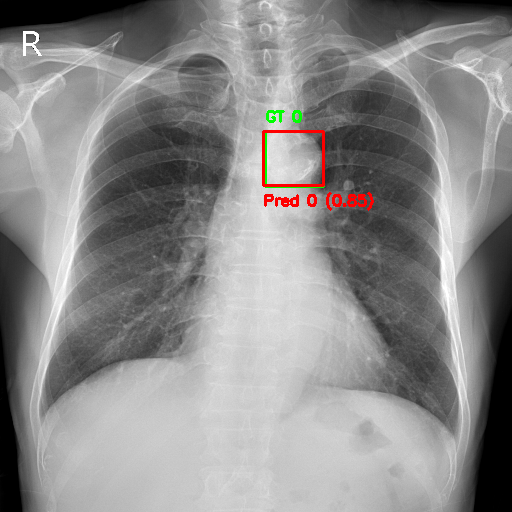

In [14]:
# ==========================================
# INFERENCE & VISUAL COMPARISON
# ==========================================
import os
import random
import cv2
from ultralytics import YOLOv10
from google.colab.patches import cv2_imshow

# 1. Define paths (Using validation set to test unseen data)
VAL_IMG_DIR = f'{BASE_DIR}/images/val'
VAL_LBL_DIR = f'{BASE_DIR}/labels/val'
MODEL_PATH = '/content/best_model1.pt'

# 2. Load the best trained model
print("Loading the trained model for inference...")
model = YOLOv10(MODEL_PATH)

# Fetch all images in the validation directory
img_files = [f for f in os.listdir(VAL_IMG_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if img_files:
    # 3. Randomly select one image
    sample_img = random.choice(img_files)
    img_path = os.path.join(VAL_IMG_DIR, sample_img)
    base_name = os.path.splitext(sample_img)[0]
    lbl_path = os.path.join(VAL_LBL_DIR, f"{base_name}.txt")

    # Read image using OpenCV
    img = cv2.imread(img_path)

    if img is not None:
        h, w, _ = img.shape
        print(f"\n✅ Image: {sample_img} | Dimensions: {w}x{h}")
        print("🟢 GREEN boxes: Ground Truth (Actual)")
        print("🔴 RED boxes: Model Predictions\n")

        # ---------------------------------------------------------
        # STEP A: Draw GROUND TRUTH boxes (Green)
        # ---------------------------------------------------------
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(float(parts[0]))
                        x_c, y_c, bw, bh = map(float, parts[1:5])

                        # Convert YOLO format to pixel coordinates
                        x1 = int((x_c - bw / 2) * w)
                        y1 = int((y_c - bh / 2) * h)
                        x2 = int((x_c + bw / 2) * w)
                        y2 = int((y_c + bh / 2) * h)

                        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                        cv2.putText(img, f"GT {class_id}", (x1, max(y1 - 10, 10)),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        else:
            print("No ground truth labels found (Normal/Background Image).")

        # ---------------------------------------------------------
        # STEP B: Run INFERENCE and draw PREDICTED boxes (Red)
        # ---------------------------------------------------------
        # conf: Confidence threshold. iou: NMS threshold
        results = model.predict(source=img_path, conf=0.15, iou=0.5, verbose=False)

        for result in results:
            boxes = result.boxes
            for box in boxes:
                # Extract coordinates, confidence, and class ID
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                conf = float(box.conf[0])
                cls = int(box.cls[0])

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
                # Position predicted label slightly below the box or inside to avoid overlap
                cv2.putText(img, f"Pred {cls} ({conf:.2f})", (x1, min(y2 + 20, h - 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        # 4. Display the overlaid image
        cv2_imshow(img)
else:
    print("No images found in the validation directory.")

In [9]:
# ==========================================
# COMPREHENSIVE MODEL EVALUATION WITH TTA (VALIDATION)
# ==========================================
from ultralytics import YOLO

# 1. Path to your best model
weights_path = '/content/model_yolov10l.pt'
print("Loading model and activating TTA mode...")
model = YOLO(weights_path)

print("Starting evaluation on Validation set...")
# 2. Run evaluation with augment=True
metrics = model.val(
    data=f'{BASE_DIR}/data.yaml',
    imgsz=512,        # Match the image size used during training
    batch=128,        # Batch size for evaluation phase
    augment=True,     # <--- KEY: Activate Test-Time Augmentation
    split='val',      # Ensure it runs on the Validation set
    conf=0.121,       # Very low confidence threshold for accurate mAP calculation
    iou=0.6           # NMS threshold to remove overlapping boxes
)

print("✅ Evaluation complete!")
print(f"🏆 Overall mAP@50 score (with TTA): {metrics.box.map50:.4f}")
print(f"🏆 Overall mAP@50-95 score (with TTA): {metrics.box.map:.4f}")

Loading model and activating TTA mode...
Starting evaluation on Validation set...
Ultralytics YOLOv8.1.34 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10s summary (fused): 293 layers, 8045796 parameters, 0 gradients, 24.5 GFLOPs


val: Scanning /content/vinbigdata_yolo/labels/val.cache... 1179 images, 300 backgrounds, 0 corrupt: 100%|██████████| 1179/1179 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:33<00:00,  3.35s/it]


                   all       1179       4461       0.76      0.343      0.572      0.424
    Aortic enlargement       1179        635      0.924      0.762      0.863       0.67
           Atelectasis       1179         41        0.7      0.171      0.441      0.348
         Calcification       1179        137      0.644      0.212      0.447      0.308
          Cardiomegaly       1179        464        0.9      0.836      0.898      0.732
         Consolidation       1179         68      0.783      0.265      0.544      0.449
                   ILD       1179        130       0.88      0.338      0.624      0.496
          Infiltration       1179        180      0.822      0.206       0.53      0.408
          Lung Opacity       1179        379      0.585      0.182      0.392      0.263
           Nodule/Mass       1179        304      0.653      0.217      0.456      0.305
          Other lesion       1179        367      0.746      0.136      0.449       0.28
      Pleural effusio

Loading the trained model for inference...

✅ Image: 8bd240f5570f1b719b7155f3ca91271a.png | Dimensions: 512x512
🟢 GREEN boxes: Ground Truth (Actual)
🔴 RED boxes: Model Predictions



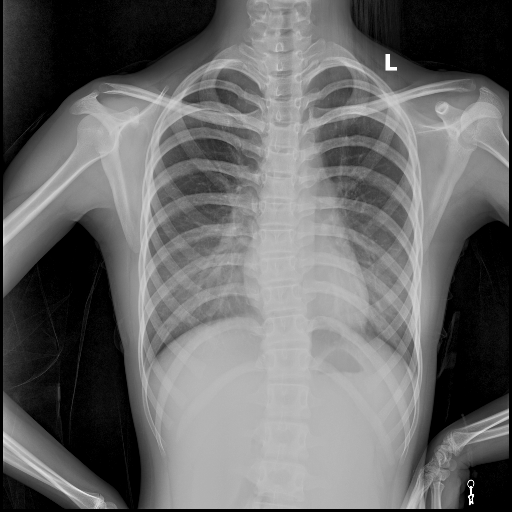

In [10]:
# ==========================================
# INFERENCE & VISUAL COMPARISON
# ==========================================
import os
import random
import cv2
from ultralytics import YOLOv10
from google.colab.patches import cv2_imshow

# 1. Define paths (Using validation set to test unseen data)
VAL_IMG_DIR = f'{BASE_DIR}/images/val'
VAL_LBL_DIR = f'{BASE_DIR}/labels/val'
MODEL_PATH = '/content/best_model3.pt'

# 2. Load the best trained model
print("Loading the trained model for inference...")
model = YOLOv10(MODEL_PATH)

# Fetch all images in the validation directory
img_files = [f for f in os.listdir(VAL_IMG_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if img_files:
    # 3. Randomly select one image
    sample_img = random.choice(img_files)
    img_path = os.path.join(VAL_IMG_DIR, sample_img)
    base_name = os.path.splitext(sample_img)[0]
    lbl_path = os.path.join(VAL_LBL_DIR, f"{base_name}.txt")

    # Read image using OpenCV
    img = cv2.imread(img_path)

    if img is not None:
        h, w, _ = img.shape
        print(f"\n✅ Image: {sample_img} | Dimensions: {w}x{h}")
        print("🟢 GREEN boxes: Ground Truth (Actual)")
        print("🔴 RED boxes: Model Predictions\n")

        # ---------------------------------------------------------
        # STEP A: Draw GROUND TRUTH boxes (Green)
        # ---------------------------------------------------------
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(float(parts[0]))
                        x_c, y_c, bw, bh = map(float, parts[1:5])

                        # Convert YOLO format to pixel coordinates
                        x1 = int((x_c - bw / 2) * w)
                        y1 = int((y_c - bh / 2) * h)
                        x2 = int((x_c + bw / 2) * w)
                        y2 = int((y_c + bh / 2) * h)

                        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                        cv2.putText(img, f"GT {class_id}", (x1, max(y1 - 10, 10)),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        else:
            print("No ground truth labels found (Normal/Background Image).")

        # ---------------------------------------------------------
        # STEP B: Run INFERENCE and draw PREDICTED boxes (Red)
        # ---------------------------------------------------------
        # conf: Confidence threshold. iou: NMS threshold
        results = model.predict(source=img_path, conf=0.15, iou=0.5, verbose=False)

        for result in results:
            boxes = result.boxes
            for box in boxes:
                # Extract coordinates, confidence, and class ID
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                conf = float(box.conf[0])
                cls = int(box.cls[0])

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
                # Position predicted label slightly below the box or inside to avoid overlap
                cv2.putText(img, f"Pred {cls} ({conf:.2f})", (x1, min(y2 + 20, h - 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        # 4. Display the overlaid image
        cv2_imshow(img)
else:
    print("No images found in the validation directory.")